In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import minimize

In [2]:
DATA_DIR = Path("output")

OUTPUT_DIR = Path("model_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42

In [3]:
WHEN_CSV_PATTERN = "dataset_winsize*_when.csv"


def convert_when_to_where_dataset_path(when_dataset_path):
    """Return the matching where-dataset path for a when-dataset CSV path."""
    suffix = "_when.csv"

    return when_dataset_path.with_name(
        f"{when_dataset_path.name[:-len(suffix)]}_where.csv"
    )


when_csv_files = sorted(
    DATA_DIR.glob(WHEN_CSV_PATTERN),
    key=lambda p: float(p.stem.split("winsize", 1)[1].removesuffix("h_when")),
)


when_csv_files

[PosixPath('output/dataset_winsize0.25h_when.csv'),
 PosixPath('output/dataset_winsize0.5h_when.csv'),
 PosixPath('output/dataset_winsize1h_when.csv'),
 PosixPath('output/dataset_winsize2h_when.csv'),
 PosixPath('output/dataset_winsize3h_when.csv'),
 PosixPath('output/dataset_winsize4h_when.csv'),
 PosixPath('output/dataset_winsize5h_when.csv'),
 PosixPath('output/dataset_winsize6h_when.csv'),
 PosixPath('output/dataset_winsize7h_when.csv'),
 PosixPath('output/dataset_winsize8h_when.csv'),
 PosixPath('output/dataset_winsize9h_when.csv'),
 PosixPath('output/dataset_winsize10h_when.csv'),
 PosixPath('output/dataset_winsize11h_when.csv'),
 PosixPath('output/dataset_winsize12h_when.csv')]

In [4]:
def load_when_where_datasets(when_dataset_path):
    where_dataset_path = convert_when_to_where_dataset_path(when_dataset_path)

    when_df = pd.read_csv(when_dataset_path)
    where_df = pd.read_csv(where_dataset_path)

    return when_df, where_df


when_df, where_df = load_when_where_datasets(when_csv_files[0])

In [5]:
# check if fold_id columns are equal
all(when_df.fold_id.to_numpy() == where_df.fold_id.to_numpy())

True

In [6]:
# load "t"s
t = when_df["label_time_to_event_seconds"].to_numpy(dtype=float)

<>:6: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:6: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
/tmp/ipykernel_36458/4053489478.py:6: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
  plt.xlabel("$\Delta t$ (hours)")


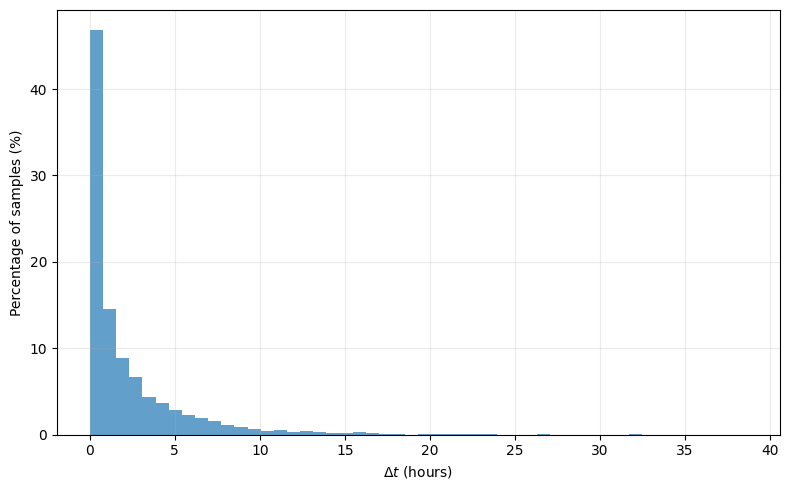

In [7]:
t_hours = t[np.isfinite(t)] / 3600
weights = np.full(t_hours.shape, 100 / len(t_hours))

plt.figure(figsize=(8, 5))
plt.hist(t_hours, bins=50, weights=weights, color="C0", alpha=0.7)
plt.xlabel("$\Delta t$ (hours)")
plt.ylabel("Percentage of samples (%)")
# plt.title("Histogram of t")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "time_to_event_histogram.pdf", dpi=300)

In [8]:
def get_truncated_exponential_pdf(t, T, lambda_):
    """PDF of a truncated exponential distribution."""
    # PDF of an exponential distribution
    num = lambda_ * np.exp(-lambda_ * t)

    # CDF of an exponential distribution
    # denum = 1 - np.exp(-lambda_ * T)
    denum = -np.expm1(-lambda_ * T)

    # Truncated PDF
    truncated_pdf = num / denum

    return truncated_pdf


def get_truncated_exponential_cdf(t, T, lambda_):
    """CDF of a truncated exponential distribution on [0, T]."""
    num = -np.expm1(-lambda_ * np.clip(t, 0, T))
    denum = -np.expm1(-lambda_ * T)

    return num / denum


def get_uniform_pdf(t, T):
    """PDF of a uniform distribution."""
    return np.ones_like(t) / T


def get_uniform_cdf(t, T):
    return np.clip(t / T, 0.0, 1.0)


def get_mixture_pdf(t, T, lambda_, p_trunc_exp):
    """Return the probability of a sample t under a mixture of truncated exponential and uniform distributions."""
    p_fg = p_trunc_exp * get_truncated_exponential_pdf(t, T, lambda_)
    p_bg = (1 - p_trunc_exp) * get_uniform_pdf(t, T)

    return p_fg + p_bg


def get_mixture_cdf(t, T, lambda_, p_trunc_exp):
    """CDF of the fitted mixture distribution on [0, T]."""
    truncated_exponential_cdf = get_truncated_exponential_cdf(t, T, lambda_)
    uniform_cdf = get_uniform_cdf(t, T)

    return p_trunc_exp * truncated_exponential_cdf + (1 - p_trunc_exp) * uniform_cdf


def negative_log_likelihood(params, t, T):
    lambda_, p_trunc_exp = params

    p = get_mixture_pdf(t, T, lambda_, p_trunc_exp)
    p = np.clip(p, 1e-30, None)

    return -np.sum(np.log(p))


def sample_from_mixture(n, T, lambda_, p_trunc_exp, random_state=42):
    """Sample from the fitted truncated-exponential/uniform mixture."""
    rng = np.random.default_rng(random_state)
    use_trunc_exp = rng.random(n) < p_trunc_exp
    samples = rng.uniform(0, T, size=n)
    u = rng.random(use_trunc_exp.sum())
    samples[use_trunc_exp] = -np.log1p(u * np.expm1(-lambda_ * T)) / lambda_
    return samples


def empirical_cdf_values(x):
    x_sorted = np.sort(x)
    y = np.arange(1, len(x_sorted) + 1) / len(x_sorted)
    return x_sorted, y


def ks_distance_to_model(x, T, lambda_, p_trunc_exp):
    x_sorted, y = empirical_cdf_values(x)
    model_y = get_mixture_cdf(x_sorted, T, lambda_, p_trunc_exp)

    return np.max(np.abs(y - model_y))

In [9]:
# iterative process
Ts = list(range(1800, int(max(t)), 900))
results, ks_errors = [], []
best_model_index = -1

for i, T in enumerate(Ts):
    # filter data
    mask = np.isfinite(t) & (t >= 0) & (t <= T)
    t_fit = t[mask]
    # print(f"Number of samples inside {T/3600.0} hours:", len(t_fit))
    # print(f"Number of samples outside {T/3600.0} hours:", len(t) - len(t_fit))

    # set solution guess
    x0 = [1 / np.median(t_fit).item(), 0.95]
    # print(f"{x0 = }")

    # fit model
    result = minimize(
        negative_log_likelihood,
        x0=x0,
        args=(t_fit, T),
        bounds=[(1e-8, 1e-2), (0.0, 1.0)],
        method="L-BFGS-B",
    )
    results.append(result)
    lambda_hat, p_trunc_exp_hat = result.x
    # print("Converged:", result.success)
    # print("p_trunc_exp:", p_trunc_exp_hat)
    # print("lambda:", lambda_hat)

    # partition bg/fg events
    weighted_fg = p_trunc_exp_hat * get_truncated_exponential_pdf(t, T, lambda_hat)
    weighted_bg = (1 - p_trunc_exp_hat) * get_uniform_pdf(t, T)
    is_bg = weighted_bg > weighted_fg

    # set threshold
    min_bg_time = min([j for i, j in zip(is_bg, t) if i]).item() / 3600
    max_fg_time = max([j for i, j in zip(is_bg, t) if not i]).item() / 3600
    threshold = (min_bg_time + max_fg_time) / 2
    # print(f"Set new threshold: {threshold = } hours")
    threshold *= 3600

    # sample from the data
    sampled_t = sample_from_mixture(
        n=len(t_fit),
        T=T,
        lambda_=lambda_hat,
        p_trunc_exp=p_trunc_exp_hat,
        random_state=RANDOM_STATE,
    )

    # compute fitting error
    raw_x, raw_y = empirical_cdf_values(t_fit)
    sample_x, sample_y = empirical_cdf_values(sampled_t)
    raw_ks = ks_distance_to_model(t_fit, T, lambda_hat, p_trunc_exp_hat)
    ks_errors.append(raw_ks)
    # print(f"Raw data KS distance to fitted CDF: {raw_ks:.4f}")

    # Visualize CDF alignment in the current fitting window.
    # grid = np.linspace(0, T, 1000)
    # plt.figure(figsize=(8, 5))
    # plt.step(raw_x / 3600, raw_y, where="post", label="Raw data empirical CDF")
    # plt.plot(
    #     grid / 3600,
    #     get_mixture_cdf(grid, T, lambda_hat, p_trunc_exp_hat),
    #     color="black",
    #     linewidth=2,
    #     label="Fitted mixture CDF",
    # )
    # plt.xlabel("Time to event (hours)")
    # plt.ylabel("CDF")
    # plt.title(f"Iteration {counter}: CDF fit within T = {T / 3600:.2f} hours")
    # plt.legend()
    # plt.grid(alpha=0.25)
    # plt.tight_layout()
    # plt.show()

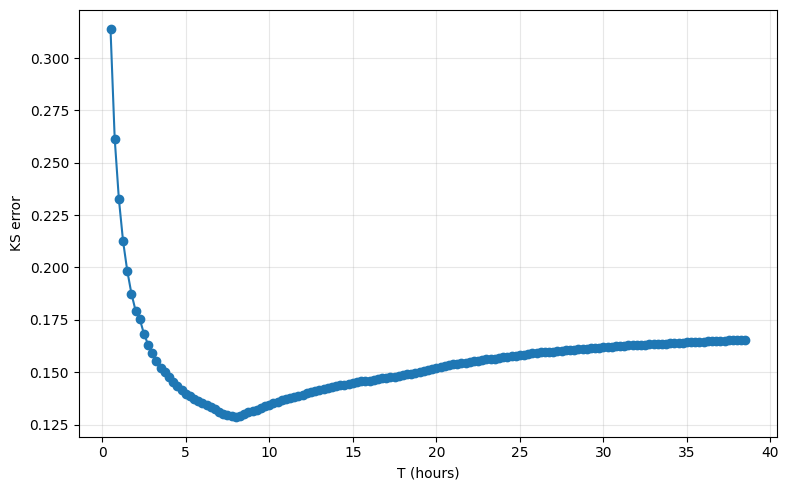

In [10]:
plt.figure(figsize=(8, 5))
plt.plot(np.array(Ts) / 3600, ks_errors, marker="o", linestyle="-")
plt.xlabel("T (hours)")
plt.ylabel("KS error")
# plt.title("KS error vs T")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "ks_error_vs_window_size.pdf", dpi=300)

In [11]:
best_fit_index = np.array(ks_errors).argmin().item()
best_T = Ts[best_fit_index]
min_error = min(ks_errors)

print(best_T / 3600, min_error)

8.0 0.12843676355066772


lambda hat: 0.64 hours
p_trunc_exp hat:0.6739
----------------------------------------
Best window size: 8.00 hours
Background samples: 1685 / 5396
Threshold: 2.12 hours
Raw vs fitted CDF KS distance: 0.1284
Raw vs sampled empirical CDF KS distance: 0.1326


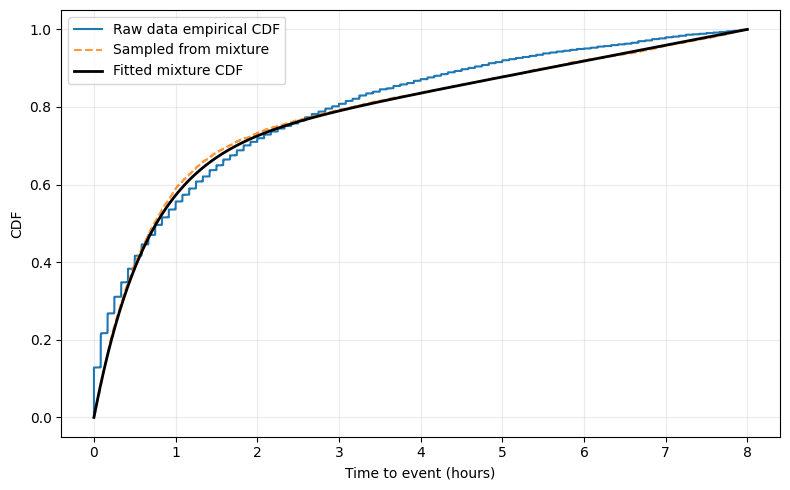

In [12]:
T = best_T
lambda_hat, p_trunc_exp_hat = results[best_fit_index].x
print(
    f"lambda hat: {(1 / lambda_hat.item()) / 3600:.2f} hours\np_trunc_exp hat:{p_trunc_exp_hat.item():.4f}"
)
print("-" * 40)

mask = np.isfinite(t) & (t >= 0) & (t <= T)
t_fit = t[mask]
raw_x, raw_y = empirical_cdf_values(t_fit)
sampled_t = sample_from_mixture(
    n=len(t_fit),
    T=T,
    lambda_=lambda_hat,
    p_trunc_exp=p_trunc_exp_hat,
    random_state=RANDOM_STATE,
)
sample_x, sample_y = empirical_cdf_values(sampled_t)
grid = np.linspace(0, T, 1000)

cdf_grid = np.sort(np.concatenate([raw_x, sample_x]))
raw_ecdf = np.searchsorted(raw_x, cdf_grid, side="right") / len(raw_x)
sample_ecdf = np.searchsorted(sample_x, cdf_grid, side="right") / len(sample_x)
raw_sample_ks = np.max(np.abs(raw_ecdf - sample_ecdf))
raw_model_ks = ks_distance_to_model(t_fit, T, lambda_hat, p_trunc_exp_hat)

weighted_fg = p_trunc_exp_hat * get_truncated_exponential_pdf(t, T, lambda_hat)
weighted_bg = (1 - p_trunc_exp_hat) * get_uniform_pdf(t, T)
is_bg = weighted_bg > weighted_fg

min_bg_time = min([j for i, j in zip(is_bg, t) if i]).item() / 3600
max_fg_time = max([j for i, j in zip(is_bg, t) if not i]).item() / 3600
threshold = (min_bg_time + max_fg_time) / 2

print(f"Best window size: {T / 3600:.2f} hours")
print(f"Background samples: {is_bg.sum()} / {len(is_bg)}")
print(f"Threshold: {threshold:.2f} hours")

print(f"Raw vs fitted CDF KS distance: {raw_model_ks:.4f}")
print(f"Raw vs sampled empirical CDF KS distance: {raw_sample_ks:.4f}")

plt.figure(figsize=(8, 5))
plt.step(raw_x / 3600, raw_y, where="post", label="Raw data empirical CDF")
plt.step(
    sample_x / 3600,
    sample_y,
    where="post",
    linestyle="--",
    alpha=0.8,
    label="Sampled from mixture",
)
plt.plot(
    grid / 3600,
    get_mixture_cdf(grid, T, lambda_hat, p_trunc_exp_hat),
    color="black",
    linewidth=2,
    label="Fitted mixture CDF",
)
plt.xlabel("Time to event (hours)")
plt.ylabel("CDF")
# plt.title(f"Best fit: CDF alignment within T = {T / 3600:.2f} hours")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "cdf_alignment.pdf", dpi=300)

# Update dataset files

In [13]:
def add_is_bg_column(df):
    if "is_bg" not in df.columns:
        df = df.copy()
        df["is_bg"] = is_bg

    return df


for when_csv_path in when_csv_files:
    where_csv_path = convert_when_to_where_dataset_path(when_csv_path)
    when_df, where_df = load_when_where_datasets(when_csv_path)

    updated_when_df = add_is_bg_column(when_df)
    updated_where_df = add_is_bg_column(where_df)

    if "is_bg" not in when_df.columns:
        updated_when_df.to_csv(when_csv_path, index=False)

    if "is_bg" not in where_df.columns:
        updated_where_df.to_csv(where_csv_path, index=False)

# comparing with null hypothesis

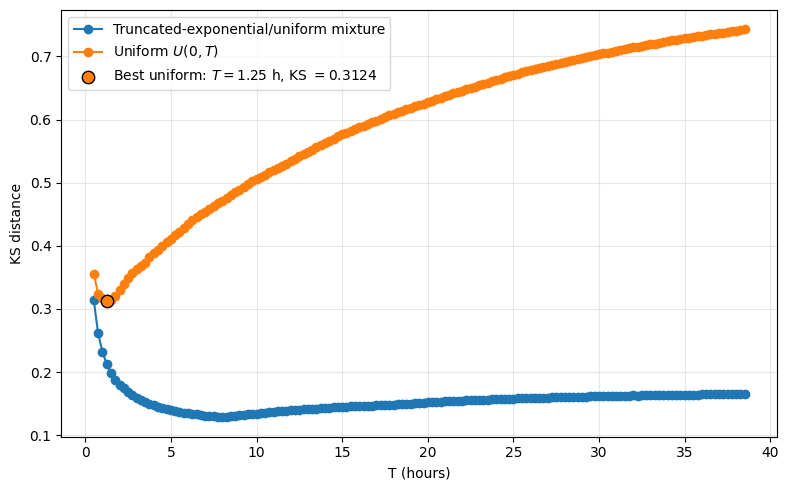

Best uniform T: 1.25 hours
Best uniform KS distance: 0.3124
Best mixture KS distance: 0.1284


In [14]:
# Fit Uniform(0, T) over the same windows used for the mixture model.
def ks_distance_to_uniform(x, T):
    """KS distance between the empirical CDF of x and Uniform(0, T)."""
    x_sorted, empirical_y = empirical_cdf_values(x)
    uniform_y = get_uniform_cdf(x_sorted, T)

    return np.max(np.abs(empirical_y - uniform_y))


uniform_ks_errors = []
for T_candidate in Ts:
    mask = np.isfinite(t) & (t >= 0) & (t <= T_candidate)
    t_fit_uniform = t[mask]
    uniform_ks_errors.append(ks_distance_to_uniform(t_fit_uniform, T_candidate))

best_uniform_index = np.argmin(uniform_ks_errors).item()
best_uniform_T = Ts[best_uniform_index]
best_uniform_ks = uniform_ks_errors[best_uniform_index]

fig, ax = plt.subplots(figsize=(8, 5))
T_hours = np.asarray(Ts) / 3600
ax.plot(
    T_hours,
    ks_errors,
    marker="o",
    label="Truncated-exponential/uniform mixture",
)
ax.plot(
    T_hours,
    uniform_ks_errors,
    marker="o",
    label=r"Uniform $U(0,T)$",
)
ax.scatter(
    best_uniform_T / 3600,
    best_uniform_ks,
    color="C1",
    edgecolor="black",
    s=80,
    zorder=3,
    label=(
        rf"Best uniform: $T={best_uniform_T / 3600:.2f}$ h, "
        rf"KS $={best_uniform_ks:.4f}$"
    ),
)
ax.set_xlabel("T (hours)")
ax.set_ylabel("KS distance")
ax.grid(alpha=0.3)
ax.legend()
fig.tight_layout()
fig.savefig(
    OUTPUT_DIR / "ks_distance_mixture_vs_uniform.pdf",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

print(f"Best uniform T: {best_uniform_T / 3600:.2f} hours")
print(f"Best uniform KS distance: {best_uniform_ks:.4f}")
print(f"Best mixture KS distance: {min_error:.4f}")

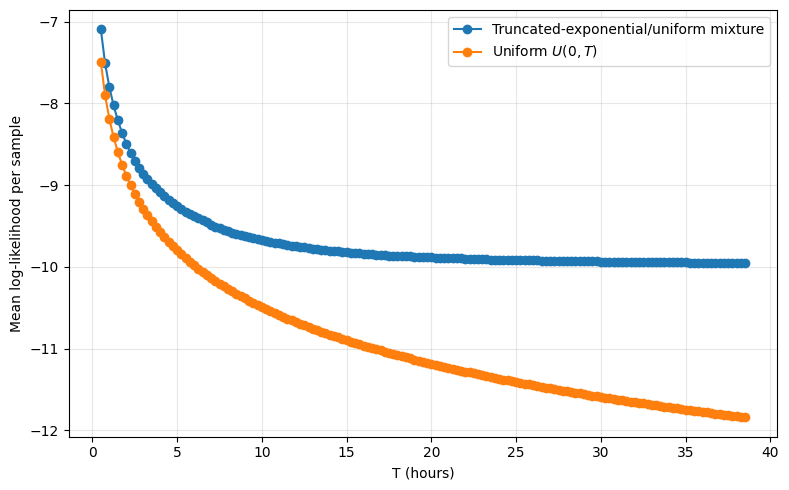

Best mixture mean log-likelihood: T=0.50 hours, value=-7.0949
Best uniform mean log-likelihood: T=0.50 hours, value=-7.4955


In [15]:
# Compare likelihood profiles using the same samples in each T window.
# Log-likelihood avoids numerical underflow; dividing by the sample count
# makes windows containing different numbers of observations easier to compare.
mixture_mean_log_likelihoods = []
uniform_mean_log_likelihoods = []
likelihood_sample_counts = []

for T_candidate, result in zip(Ts, results):
    mask = np.isfinite(t) & (t >= 0) & (t <= T_candidate)
    t_likelihood = t[mask]
    n_samples = len(t_likelihood)

    lambda_candidate, p_candidate = result.x
    mixture_density = get_mixture_pdf(
        t_likelihood, T_candidate, lambda_candidate, p_candidate
    )
    uniform_density = get_uniform_pdf(t_likelihood, T_candidate)

    mixture_log_likelihood = np.log(np.clip(mixture_density, 1e-30, None)).sum()
    uniform_log_likelihood = np.log(np.clip(uniform_density, 1e-30, None)).sum()

    mixture_mean_log_likelihoods.append(mixture_log_likelihood / n_samples)
    uniform_mean_log_likelihoods.append(uniform_log_likelihood / n_samples)
    likelihood_sample_counts.append(n_samples)

best_mixture_likelihood_index = np.argmax(mixture_mean_log_likelihoods).item()
best_uniform_likelihood_index = np.argmax(uniform_mean_log_likelihoods).item()

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(
    T_hours,
    mixture_mean_log_likelihoods,
    marker="o",
    label="Truncated-exponential/uniform mixture",
)
ax.plot(
    T_hours,
    uniform_mean_log_likelihoods,
    marker="o",
    label=r"Uniform $U(0,T)$",
)
ax.set_xlabel("T (hours)")
ax.set_ylabel("Mean log-likelihood per sample")
ax.grid(alpha=0.3)
ax.legend()
fig.tight_layout()
fig.savefig(
    OUTPUT_DIR / "log_likelihood_mixture_vs_uniform.pdf",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

print(
    "Best mixture mean log-likelihood: "
    f"T={Ts[best_mixture_likelihood_index] / 3600:.2f} hours, "
    f"value={mixture_mean_log_likelihoods[best_mixture_likelihood_index]:.4f}"
)
print(
    "Best uniform mean log-likelihood: "
    f"T={Ts[best_uniform_likelihood_index] / 3600:.2f} hours, "
    f"value={uniform_mean_log_likelihoods[best_uniform_likelihood_index]:.4f}"
)